In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_PATH = "../data/raw/industrial_operations_timeseries.csv"

df = pd.read_csv(DATA_PATH)
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)

df.head()

,timestamp,hour,day_of_week,month,is_weekend,shift,ambient_temperature_c,production_throughput_units,maintenance_event,energy_consumption_kwh,anomaly_event,energy_price_usd_per_kwh,estimated_energy_cost_usd
0,2023-01-01 00:00:00,0,6,1,1,night,23.87,51.14,1,450.59,0,0.09,40.55
1,2023-01-01 01:00:00,1,6,1,1,night,23.02,57.50,1,393.22,0,0.09,35.39
2,2023-01-01 02:00:00,2,6,1,1,night,24.49,47.10,1,339.65,0,0.09,30.57
3,2023-01-01 03:00:00,3,6,1,1,night,26.28,58.33,1,416.23,0,0.09,37.46
4,2023-01-01 04:00:00,4,6,1,1,night,24.27,58.11,1,384.62,0,0.09,34.62


In [2]:
print("Dataset shape:")
print(df.shape)

print("\nDate range:")
print(df["timestamp"].min())
print(df["timestamp"].max())

print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Dataset shape:
(26304, 13)

Date range:
2023-01-01 00:00:00
2025-12-31 23:00:00

Columns:
['timestamp', 'hour', 'day_of_week', 'month', 'is_weekend', 'shift', 'ambient_temperature_c', 'production_throughput_units', 'maintenance_event', 'energy_consumption_kwh', 'anomaly_event', 'energy_price_usd_per_kwh', 'estimated_energy_cost_usd']

Data types:
timestamp                      datetime64[ns]
hour                                    int64
day_of_week                             int64
month                                   int64
is_weekend                              int64
shift                                  object
ambient_temperature_c                 float64
production_throughput_units           float64
maintenance_event                       int64
energy_consumption_kwh                float64
anomaly_event                           int64
energy_price_usd_per_kwh              float64
estimated_energy_cost_usd             float64
dtype: object


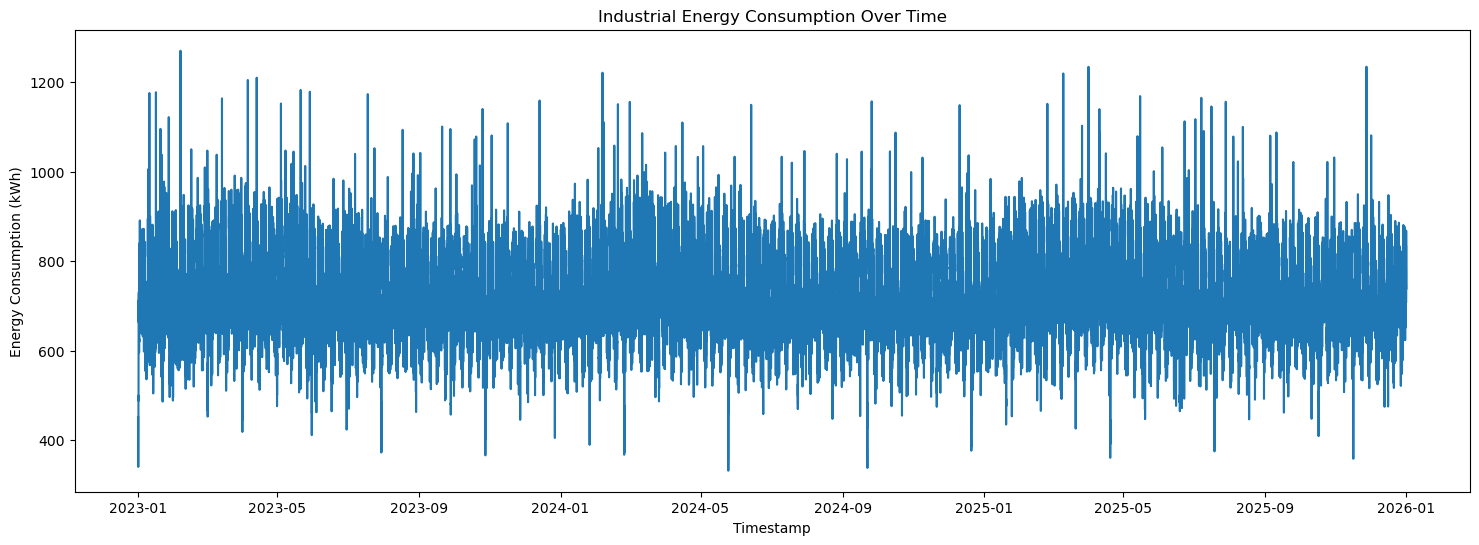

In [3]:
plt.figure(figsize=(18,6))

plt.plot(
    df["timestamp"],
    df["energy_consumption_kwh"]
)

plt.title("Industrial Energy Consumption Over Time")
plt.xlabel("Timestamp")
plt.ylabel("Energy Consumption (kWh)")

plt.show()

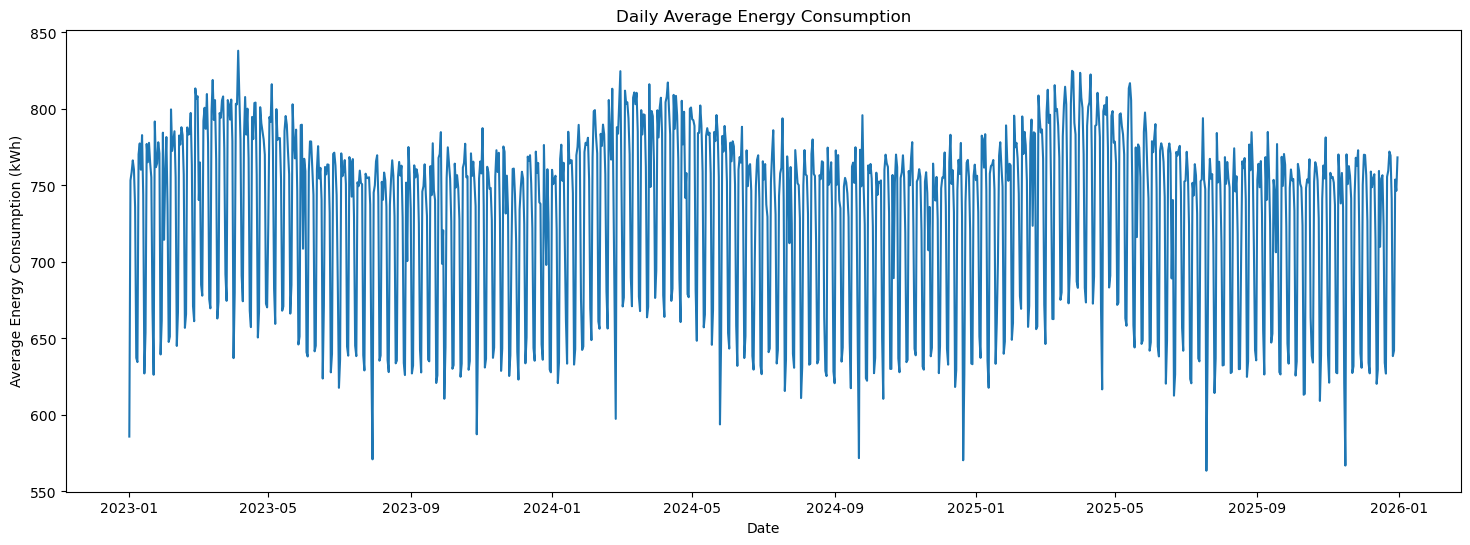

In [4]:
daily_energy = (
    df
    .set_index("timestamp")
    ["energy_consumption_kwh"]
    .resample("D")
    .mean()
)

plt.figure(figsize=(18,6))

plt.plot(
    daily_energy.index,
    daily_energy.values
)

plt.title("Daily Average Energy Consumption")
plt.xlabel("Date")
plt.ylabel("Average Energy Consumption (kWh)")

plt.show()

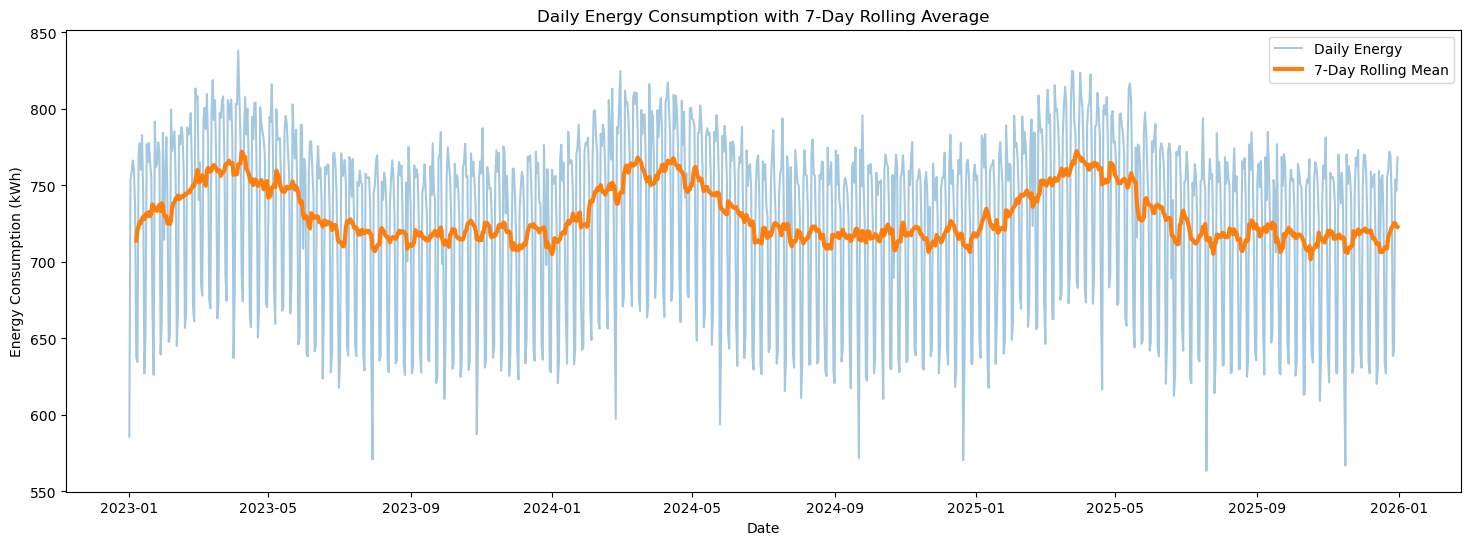

In [5]:
daily_rolling_7d = daily_energy.rolling(window=7).mean()

plt.figure(figsize=(18,6))

plt.plot(
    daily_energy.index,
    daily_energy.values,
    alpha=0.4,
    label="Daily Energy"
)

plt.plot(
    daily_rolling_7d.index,
    daily_rolling_7d.values,
    linewidth=3,
    label="7-Day Rolling Mean"
)

plt.title("Daily Energy Consumption with 7-Day Rolling Average")
plt.xlabel("Date")
plt.ylabel("Energy Consumption (kWh)")

plt.legend()

plt.show()

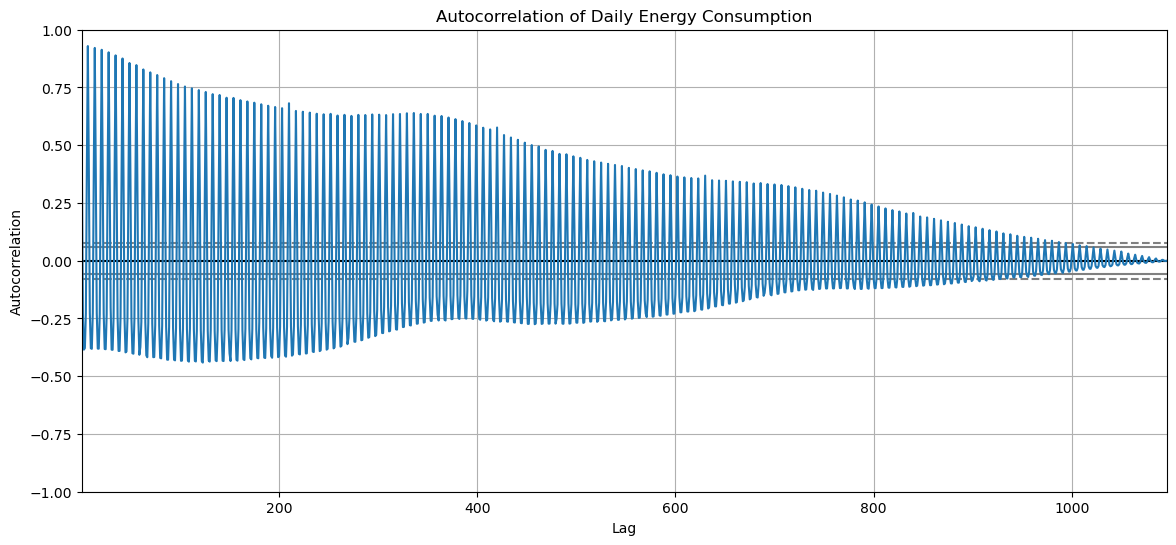

In [6]:
from pandas.plotting import autocorrelation_plot

plt.figure(figsize=(14,6))

autocorrelation_plot(daily_energy)

plt.title("Autocorrelation of Daily Energy Consumption")

plt.show()

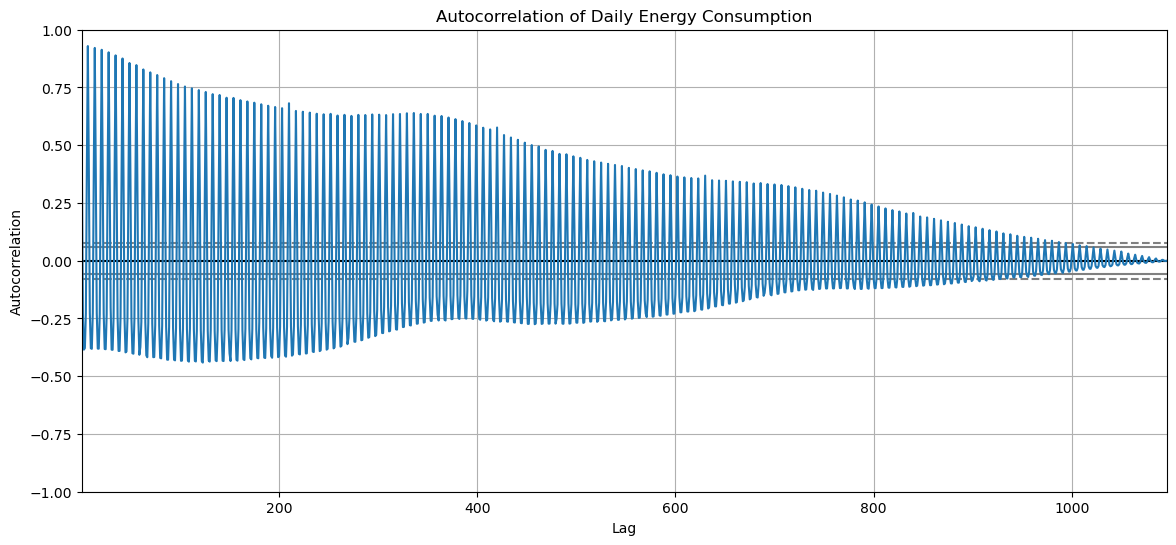

In [8]:
from pandas.plotting import autocorrelation_plot

plt.figure(figsize=(14,6))

autocorrelation_plot(daily_energy)

plt.title("Autocorrelation of Daily Energy Consumption")

plt.show()

In [9]:
train_size = int(len(df) * 0.8)

train_df = df.iloc[:train_size]
test_df = df.iloc[train_size:]

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

print("\nTrain date range:")
print(train_df["timestamp"].min())
print(train_df["timestamp"].max())

print("\nTest date range:")
print(test_df["timestamp"].min())
print(test_df["timestamp"].max())

Train shape: (21043, 13)
Test shape: (5261, 13)

Train date range:
2023-01-01 00:00:00
2025-05-26 18:00:00

Test date range:
2025-05-26 19:00:00
2025-12-31 23:00:00


In [10]:
df_features = df.copy()

df_features["lag_1"] = df_features["energy_consumption_kwh"].shift(1)
df_features["lag_24"] = df_features["energy_consumption_kwh"].shift(24)
df_features["lag_168"] = df_features["energy_consumption_kwh"].shift(168)

df_features[
    [
        "timestamp",
        "energy_consumption_kwh",
        "lag_1",
        "lag_24",
        "lag_168"
    ]
].head(30)

,timestamp,energy_consumption_kwh,lag_1,lag_24,lag_168
0,2023-01-01 00:00:00,450.59,NaN,NaN,NaN
1,2023-01-01 01:00:00,393.22,450.59,NaN,NaN
2,2023-01-01 02:00:00,339.65,393.22,NaN,NaN
3,2023-01-01 03:00:00,416.23,339.65,NaN,NaN
4,2023-01-01 04:00:00,384.62,416.23,NaN,NaN
5,2023-01-01 05:00:00,448.77,384.62,NaN,NaN
6,2023-01-01 06:00:00,499.47,448.77,NaN,NaN
7,2023-01-01 07:00:00,487.48,499.47,NaN,NaN
8,2023-01-01 08:00:00,636.81,487.48,NaN,NaN
9,2023-01-01 09:00:00,712.67,636.81,NaN,NaN


In [11]:
df_features["rolling_mean_24"] = (
    df_features["energy_consumption_kwh"]
    .rolling(window=24)
    .mean()
)

df_features["rolling_std_24"] = (
    df_features["energy_consumption_kwh"]
    .rolling(window=24)
    .std()
)

df_features[
    [
        "timestamp",
        "energy_consumption_kwh",
        "rolling_mean_24",
        "rolling_std_24"
    ]
].head(30)

,timestamp,energy_consumption_kwh,rolling_mean_24,rolling_std_24
0,2023-01-01 00:00:00,450.59,NaN,NaN
1,2023-01-01 01:00:00,393.22,NaN,NaN
2,2023-01-01 02:00:00,339.65,NaN,NaN
3,2023-01-01 03:00:00,416.23,NaN,NaN
4,2023-01-01 04:00:00,384.62,NaN,NaN
5,2023-01-01 05:00:00,448.77,NaN,NaN
6,2023-01-01 06:00:00,499.47,NaN,NaN
7,2023-01-01 07:00:00,487.48,NaN,NaN
8,2023-01-01 08:00:00,636.81,NaN,NaN
9,2023-01-01 09:00:00,712.67,NaN,NaN


In [12]:
df_features_clean = df_features.dropna().copy()

print("Original shape:")
print(df_features.shape)

print("\nClean shape:")
print(df_features_clean.shape)

print("\nRemaining missing values:")
print(df_features_clean.isna().sum().sum())

Original shape:
(26304, 18)

Clean shape:
(26136, 18)

Remaining missing values:
0


In [13]:
feature_columns = [
    "hour",
    "day_of_week",
    "month",
    "is_weekend",
    "ambient_temperature_c",
    "production_throughput_units",
    "maintenance_event",
    "anomaly_event",
    "lag_1",
    "lag_24",
    "lag_168",
    "rolling_mean_24",
    "rolling_std_24"
]

target_column = "energy_consumption_kwh"

X = df_features_clean[feature_columns]
y = df_features_clean[target_column]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeatures:")
print(feature_columns)

Feature matrix shape: (26136, 13)
Target shape: (26136,)

Features:
['hour', 'day_of_week', 'month', 'is_weekend', 'ambient_temperature_c', 'production_throughput_units', 'maintenance_event', 'anomaly_event', 'lag_1', 'lag_24', 'lag_168', 'rolling_mean_24', 'rolling_std_24']


In [14]:
split_index = int(len(df_features_clean) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (20908, 13)
X_test: (5228, 13)
y_train: (20908,)
y_test: (5228,)


In [15]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

print("Model trained successfully.")

Model trained successfully.


In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Model Evaluation")
print("----------------")
print(f"MAE:  {mae:.2f} kWh")
print(f"RMSE: {rmse:.2f} kWh")
print(f"R²:   {r2:.4f}")

Model Evaluation
----------------
MAE:  29.05 kWh
RMSE: 36.20 kWh
R²:   0.8431


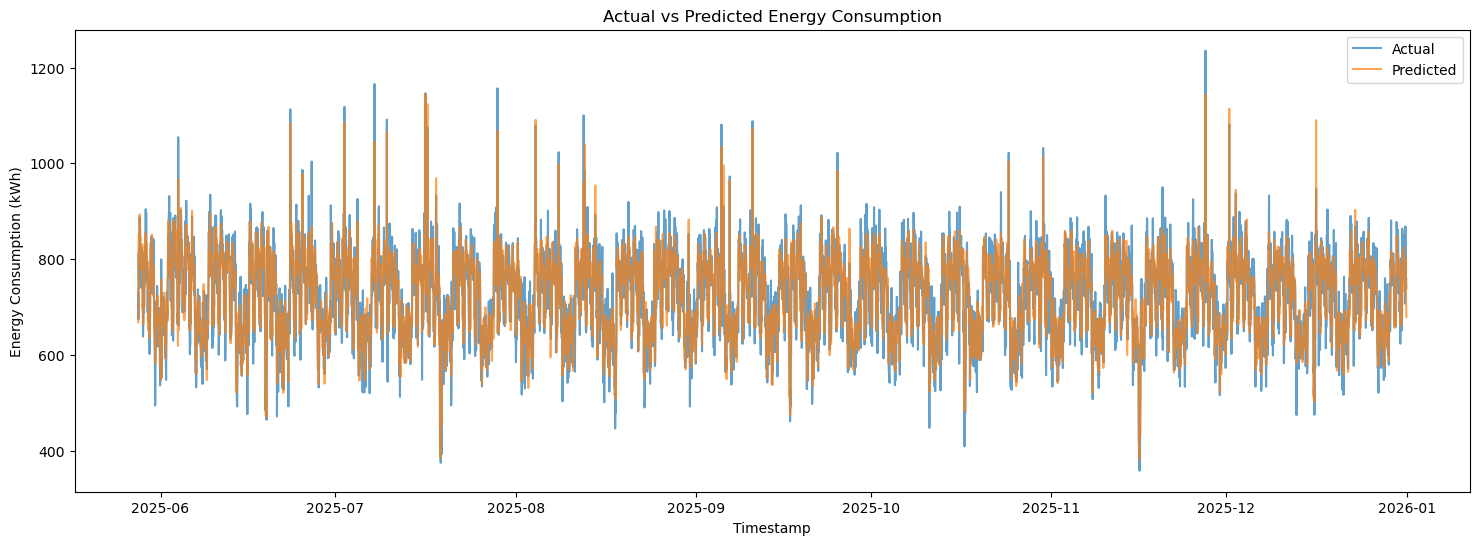

In [17]:
results_df = pd.DataFrame({
    "timestamp": df_features_clean.iloc[split_index:]["timestamp"],
    "actual": y_test.values,
    "predicted": y_pred
})

plt.figure(figsize=(18,6))

plt.plot(
    results_df["timestamp"],
    results_df["actual"],
    label="Actual",
    alpha=0.7
)

plt.plot(
    results_df["timestamp"],
    results_df["predicted"],
    label="Predicted",
    alpha=0.7
)

plt.title("Actual vs Predicted Energy Consumption")
plt.xlabel("Timestamp")
plt.ylabel("Energy Consumption (kWh)")

plt.legend()

plt.show()

In [18]:
feature_importance_df = pd.DataFrame({
    "feature": feature_columns,
    "importance": model.feature_importances_
})

feature_importance_df = feature_importance_df.sort_values(
    by="importance",
    ascending=False
)

print(feature_importance_df)

                        feature  importance
5   production_throughput_units    0.726640
4         ambient_temperature_c    0.075334
7                 anomaly_event    0.053793
6             maintenance_event    0.037806
12               rolling_std_24    0.020785
8                         lag_1    0.017610
11              rolling_mean_24    0.017400
10                      lag_168    0.016811
9                        lag_24    0.015669
0                          hour    0.008452
2                         month    0.006202
1                   day_of_week    0.003394
3                    is_weekend    0.000105


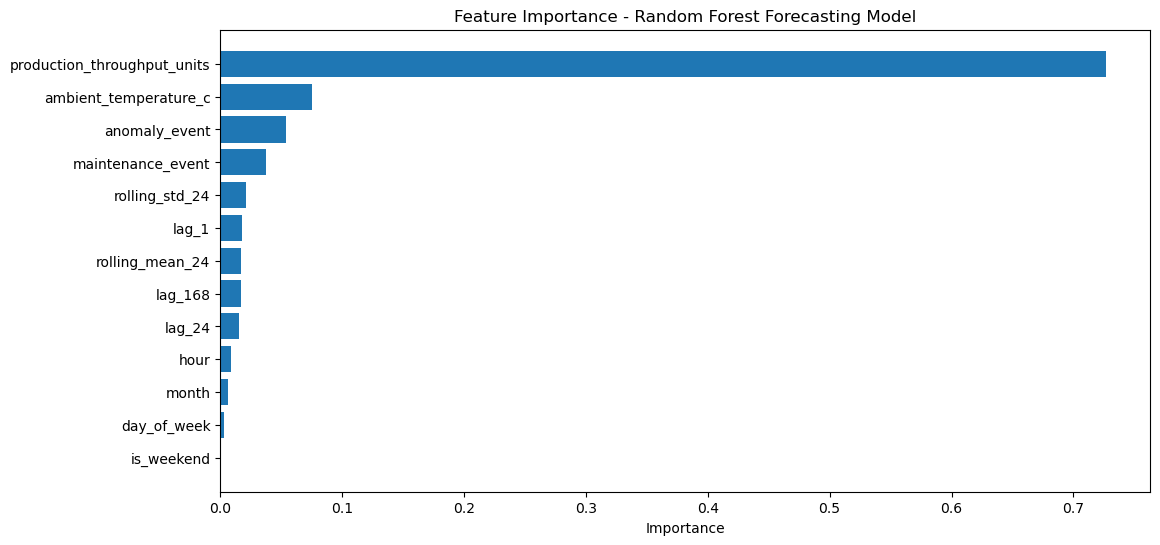

In [19]:
plt.figure(figsize=(12,6))

plt.barh(
    feature_importance_df["feature"],
    feature_importance_df["importance"]
)

plt.gca().invert_yaxis()

plt.title("Feature Importance - Random Forest Forecasting Model")
plt.xlabel("Importance")

plt.show()

In [20]:
results_df["absolute_error"] = abs(results_df["actual"] - results_df["predicted"])
results_df["percentage_error"] = (results_df["absolute_error"] / results_df["actual"]) * 100

results_df["hour"] = results_df["timestamp"].dt.hour

results_df["energy_price_usd_per_kwh"] = np.select(
    [
        results_df["hour"].between(18, 22),
        results_df["hour"].between(8, 17),
    ],
    [
        0.18,
        0.13,
    ],
    default=0.09,
)

results_df["actual_cost_usd"] = (
    results_df["actual"] * results_df["energy_price_usd_per_kwh"]
)

results_df["predicted_cost_usd"] = (
    results_df["predicted"] * results_df["energy_price_usd_per_kwh"]
)

summary = {
    "avg_actual_kwh": results_df["actual"].mean(),
    "avg_predicted_kwh": results_df["predicted"].mean(),
    "avg_absolute_error_kwh": results_df["absolute_error"].mean(),
    "avg_percentage_error": results_df["percentage_error"].mean(),
    "total_actual_cost_usd": results_df["actual_cost_usd"].sum(),
    "total_predicted_cost_usd": results_df["predicted_cost_usd"].sum(),
    "cost_forecast_error_usd": (
        results_df["predicted_cost_usd"].sum()
        - results_df["actual_cost_usd"].sum()
    ),
    "peak_actual_kwh": results_df["actual"].max(),
    "peak_predicted_kwh": results_df["predicted"].max(),
}

summary

{'avg_actual_kwh': np.float64(718.282006503443),
 'avg_predicted_kwh': np.float64(718.6417571346595),
 'avg_absolute_error_kwh': np.float64(29.045216315990825),
 'avg_percentage_error': np.float64(4.113045995075937),
 'total_actual_cost_usd': np.float64(474596.05150000006),
 'total_predicted_cost_usd': np.float64(474887.607722),
 'cost_forecast_error_usd': np.float64(291.5562219999265),
 'peak_actual_kwh': 1235.1,
 'peak_predicted_kwh': 1145.2158999999995}